In [1]:
import pandas as pd
import numpy as np

In [3]:
from google.colab import files
import io

# Upload file manually
uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]

# Read Excel file
df_2009 = pd.read_excel(io.BytesIO(uploaded[file_name]), sheet_name="Year 2009-2010")
df_2010 = pd.read_excel(io.BytesIO(uploaded[file_name]), sheet_name="Year 2010-2011")

print("2009-2010 shape:", df_2009.shape)
print("2010-2011 shape:", df_2010.shape)

Saving online_retail_II.xlsx to online_retail_II.xlsx
2009-2010 shape: (525461, 8)
2010-2011 shape: (541910, 8)


In [4]:
df_2009["SourceYear"] = "2009-2010"
df_2010["SourceYear"] = "2010-2011"

df = pd.concat([df_2009, df_2010], ignore_index=True)

print("Combined dataset shape:", df.shape)

Combined dataset shape: (1067371, 9)


In [5]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.columns.tolist())

['invoice', 'stockcode', 'description', 'quantity', 'invoicedate', 'price', 'customer_id', 'country', 'sourceyear']


In [6]:
df.head()

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,sourceyear
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,2009-2010


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   invoice      1067371 non-null  object        
 1   stockcode    1067371 non-null  object        
 2   description  1062989 non-null  object        
 3   quantity     1067371 non-null  int64         
 4   invoicedate  1067371 non-null  datetime64[ns]
 5   price        1067371 non-null  float64       
 6   customer_id  824364 non-null   float64       
 7   country      1067371 non-null  object        
 8   sourceyear   1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 73.3+ MB


In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
customer_id,243007
description,4382
invoice,0
quantity,0
stockcode,0
invoicedate,0
price,0
country,0
sourceyear,0


In [9]:
df["revenue"] = df["quantity"] * df["price"]

df[["quantity", "price", "revenue"]].head()

,quantity,price,revenue
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


In [10]:
df.describe(include="all")

,invoice,stockcode,description,quantity,invoicedate,price,customer_id,country,sourceyear,revenue
count,1067371.0,1067371,1062989,1.067371e+06,1067371,1.067371e+06,824364.000000,1067371,1067371,1.067371e+06
unique,53628.0,5305,5698,NaN,NaN,NaN,NaN,43,2,NaN
top,537434.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom,2010-2011,NaN
freq,1350.0,5829,5918,NaN,NaN,NaN,NaN,981330,541910,NaN
mean,NaN,NaN,NaN,9.938898e+00,2011-01-02 21:13:55.394028544,4.649388e+00,15324.638504,NaN,NaN,1.806987e+01
min,NaN,NaN,NaN,-8.099500e+04,2009-12-01 07:45:00,-5.359436e+04,12346.000000,NaN,NaN,-1.684696e+05
25%,NaN,NaN,NaN,1.000000e+00,2010-07-09 09:46:00,1.250000e+00,13975.000000,NaN,NaN,3.750000e+00
50%,NaN,NaN,NaN,3.000000e+00,2010-12-07 15:28:00,2.100000e+00,15255.000000,NaN,NaN,9.900000e+00
75%,NaN,NaN,NaN,1.000000e+01,2011-07-22 10:23:00,4.150000e+00,16797.000000,NaN,NaN,1.770000e+01
max,NaN,NaN,NaN,8.099500e+04,2011-12-09 12:50:00,3.897000e+04,18287.000000,NaN,NaN,1.684696e+05


In [11]:
print("Number of rows:", len(df))
print("Number of unique invoices:", df["invoice"].nunique())
print("Number of unique products:", df["stockcode"].nunique())
print("Number of unique customers:", df["customer_id"].nunique())
print("Number of countries:", df["country"].nunique())

Number of rows: 1067371
Number of unique invoices: 53628
Number of unique products: 5305
Number of unique customers: 5942
Number of countries: 43


In [12]:
print("Earliest invoice date:", df["invoicedate"].min())
print("Latest invoice date:", df["invoicedate"].max())

Earliest invoice date: 2009-12-01 07:45:00
Latest invoice date: 2011-12-09 12:50:00


In [13]:
# Recreate revenue column if not already done
df["revenue"] = df["quantity"] * df["price"]

# Quick overall checks
print("Number of rows:", len(df))
print("Number of unique invoices:", df["invoice"].nunique())
print("Number of unique products:", df["stockcode"].nunique())
print("Number of unique customers:", df["customer_id"].nunique())
print("Number of countries:", df["country"].nunique())

print("\nEarliest invoice date:", df["invoicedate"].min())
print("Latest invoice date:", df["invoicedate"].max())

Number of rows: 1067371
Number of unique invoices: 53628
Number of unique products: 5305
Number of unique customers: 5942
Number of countries: 43

Earliest invoice date: 2009-12-01 07:45:00
Latest invoice date: 2011-12-09 12:50:00


In [14]:
df_clean = df[(df["quantity"] > 0) & (df["price"] > 0)].copy()

print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)

Original shape: (1067371, 10)
Clean shape: (1041671, 10)


In [15]:
df_clean["year"] = df_clean["invoicedate"].dt.year
df_clean["month"] = df_clean["invoicedate"].dt.month
df_clean["year_month"] = df_clean["invoicedate"].dt.to_period("M")

df_clean[["invoicedate", "year", "month", "year_month"]].head()

,invoicedate,year,month,year_month
0,2009-12-01 07:45:00,2009,12,2009-12
1,2009-12-01 07:45:00,2009,12,2009-12
2,2009-12-01 07:45:00,2009,12,2009-12
3,2009-12-01 07:45:00,2009,12,2009-12
4,2009-12-01 07:45:00,2009,12,2009-12


<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='year_month'>

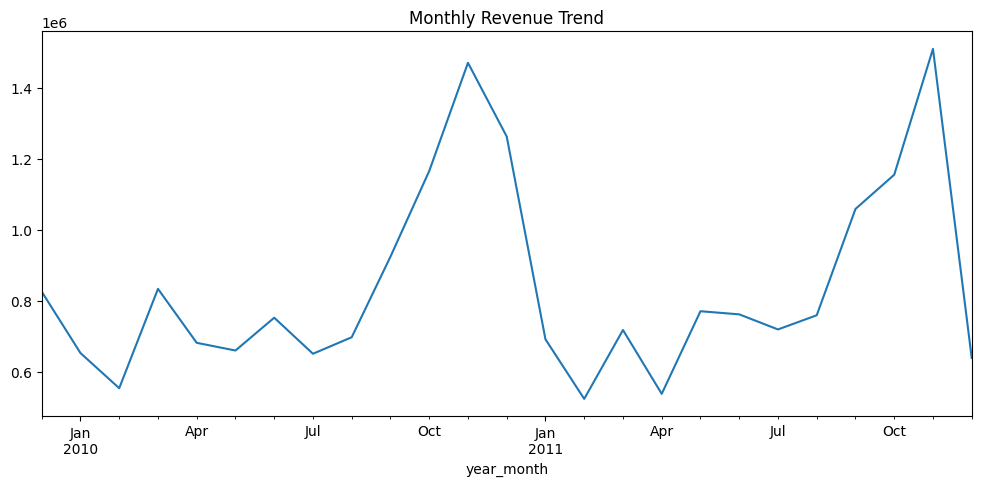

In [16]:
monthly_sales = df_clean.groupby("year_month")["revenue"].sum()

monthly_sales.plot(figsize=(12,5), title="Monthly Revenue Trend")

<Axes: title={'center': 'Top 10 Countries by Revenue'}, xlabel='country'>

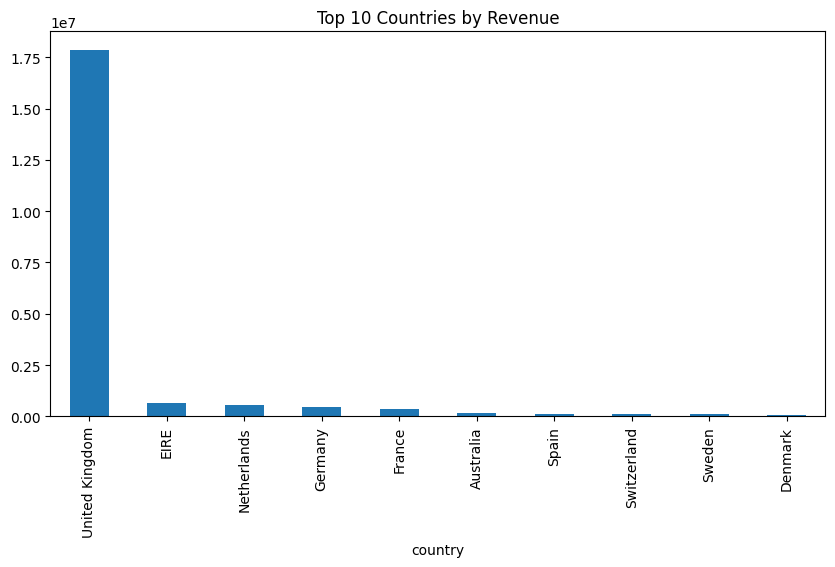

In [17]:
country_sales = (
    df_clean.groupby("country")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_sales.plot(kind="bar", figsize=(10,5), title="Top 10 Countries by Revenue")

<Axes: title={'center': 'Top 10 Products by Revenue'}, ylabel='description'>

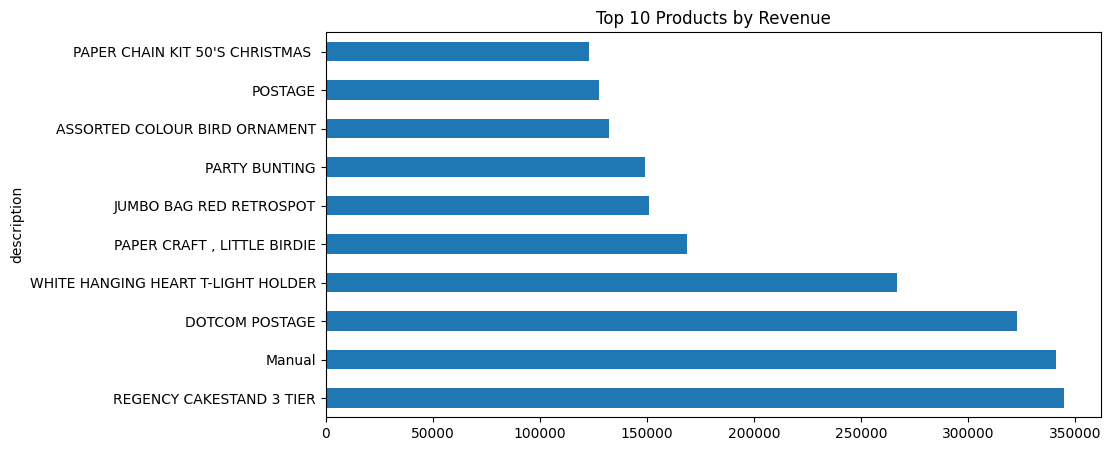

In [18]:
top_products = (
    df_clean.groupby("description")["revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products.plot(kind="barh", figsize=(10,5), title="Top 10 Products by Revenue")

<Axes: title={'center': 'Revenue Distribution'}, ylabel='Frequency'>

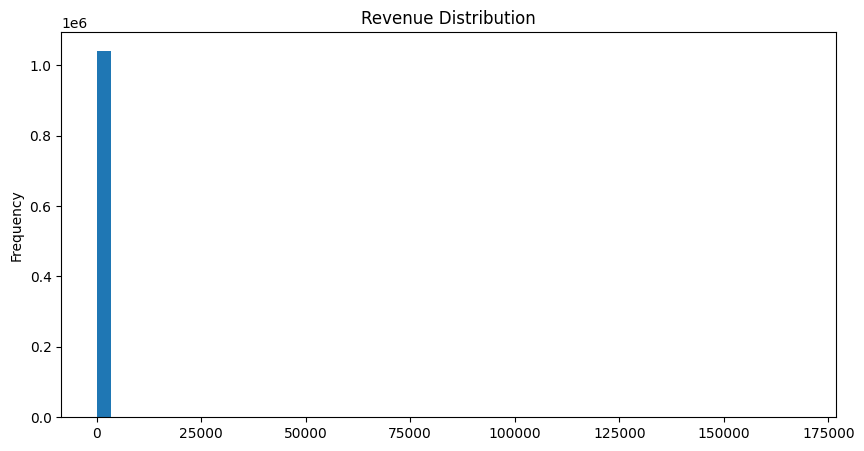

In [19]:
df_clean["revenue"].plot(kind="hist", bins=50, figsize=(10,5), title="Revenue Distribution")

In [20]:
customer_revenue = (
    df_clean.groupby("customer_id")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head()

,revenue
customer_id,
18102.0,608821.65
14646.0,528602.52
14156.0,313946.37
14911.0,295972.63
17450.0,246973.09


<Axes: title={'center': 'Top 10 Customers by Revenue'}, xlabel='customer_id'>

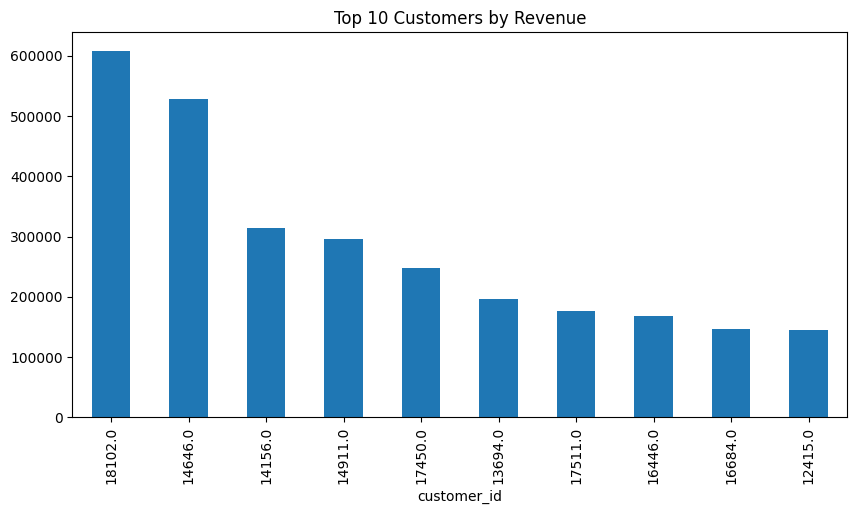

In [21]:
top_customers = customer_revenue.head(10)

top_customers.plot(kind="bar", figsize=(10,5), title="Top 10 Customers by Revenue")

In [22]:
orders_per_customer = df_clean.groupby("customer_id")["invoice"].nunique()

orders_per_customer.describe()

,invoice
count,5878.000000
mean,6.289384
std,13.009406
min,1.000000
25%,1.000000
50%,3.000000
75%,7.000000
max,398.000000


In [23]:
df_clean = df_clean[~df_clean["description"].str.contains("POSTAGE|MANUAL", case=False, na=False)]

In [24]:
df_customers = df_clean.dropna(subset=["customer_id"]).copy()

print("Shape after removing missing customers:", df_customers.shape)

Shape after removing missing customers: (802986, 13)


In [25]:
reference_date = df_customers["invoicedate"].max() + pd.Timedelta(days=1)

print("Reference date:", reference_date)

Reference date: 2011-12-10 12:50:00


In [26]:
customer_df = df_customers.groupby("customer_id").agg({
    "invoicedate": lambda x: (reference_date - x.max()).days,  # Recency
    "invoice": "nunique",                                     # Frequency
    "revenue": "sum",                                         # Monetary
    "quantity": "sum"                                         # Total items
}).reset_index()

customer_df.columns = [
    "customer_id",
    "recency_days",
    "frequency_orders",
    "total_revenue",
    "total_quantity"
]

customer_df.head()

,customer_id,recency_days,frequency_orders,total_revenue,total_quantity
0,12346.0,326,12,77556.46,74285
1,12347.0,2,8,5633.32,3286
2,12348.0,75,5,1658.40,2704
3,12349.0,19,3,3678.69,1621
4,12350.0,310,1,294.40,196


In [27]:
customer_df["avg_order_value"] = (
    customer_df["total_revenue"] / customer_df["frequency_orders"]
)

In [28]:
customer_df.describe()

,customer_id,recency_days,frequency_orders,total_revenue,total_quantity,avg_order_value
count,5862.000000,5862.000000,5862.000000,5862.000000,5862.000000,5862.000000
mean,15316.586148,200.867793,6.257250,2977.246538,1823.782839,386.969890
std,1716.167743,209.095351,12.810858,14627.261416,8970.951159,1212.217253
min,12346.000000,1.000000,1.000000,2.950000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,344.645000,191.000000,179.722083
50%,15317.500000,95.500000,3.000000,880.630000,492.000000,283.450000
75%,16799.750000,379.000000,7.000000,2286.345000,1377.750000,417.947500
max,18287.000000,739.000000,379.000000,608821.650000,367072.000000,84236.250000


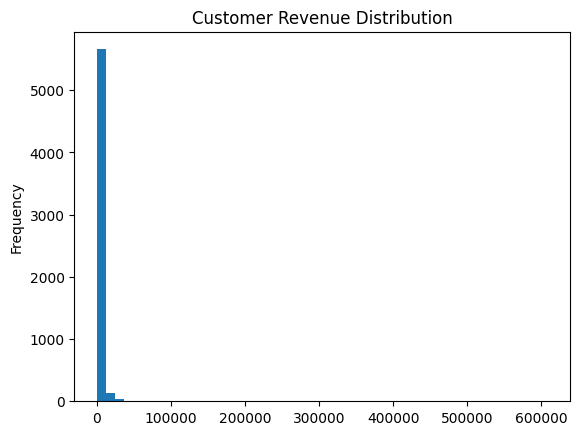

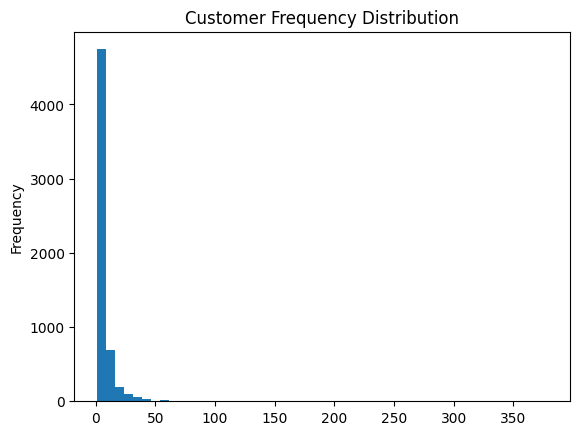

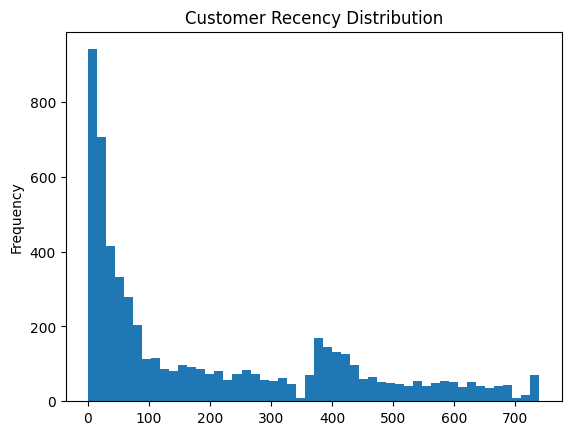

In [29]:
import matplotlib.pyplot as plt

customer_df["total_revenue"].plot(kind="hist", bins=50, title="Customer Revenue Distribution")
plt.show()

customer_df["frequency_orders"].plot(kind="hist", bins=50, title="Customer Frequency Distribution")
plt.show()

customer_df["recency_days"].plot(kind="hist", bins=50, title="Customer Recency Distribution")
plt.show()

In [30]:
customer_df.sort_values("total_revenue", ascending=False).head(10)

,customer_id,recency_days,frequency_orders,total_revenue,total_quantity,avg_order_value
5676,18102.0,1,145,608821.65,188340,4198.770000
2270,14646.0,2,145,526751.52,367072,3632.769103
1785,14156.0,10,151,305767.92,165987,2024.953113
2528,14911.0,1,379,284592.97,149968,750.904934
5036,17450.0,8,51,246973.09,84720,4842.609608
1328,13694.0,4,143,196482.81,189205,1374.005664
5095,17511.0,3,60,175603.55,119656,2926.725833
4047,16446.0,1,2,168472.50,80997,84236.250000
4281,16684.0,4,55,147142.77,104810,2675.323091
68,12415.0,24,24,144033.37,91443,6001.390417


In [31]:
import numpy as np

customer_df["log_revenue"] = np.log1p(customer_df["total_revenue"])
customer_df["log_frequency"] = np.log1p(customer_df["frequency_orders"])

In [39]:
features = [
    "recency_days",
    "frequency_orders",
    "total_quantity"
]

X = customer_df[features]
y = customer_df["log_revenue"]

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (4689, 3)
Test size: (1173, 3)


In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [42]:
y_pred = model.predict(X_test)

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 0.7849093468074596
RMSE: 1.021849888977303
R2 Score: 0.48746456772147984


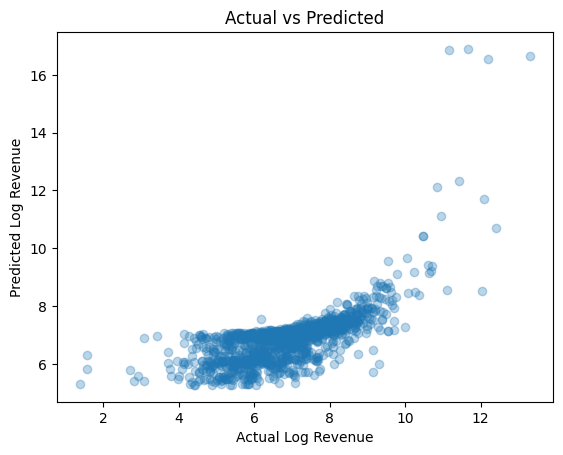

In [44]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel("Actual Log Revenue")
plt.ylabel("Predicted Log Revenue")
plt.title("Actual vs Predicted")
plt.show()

In [45]:
importance = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
}).sort_values(by="coefficient", ascending=False)

importance

,feature,coefficient
1,frequency_orders,0.043551
2,total_quantity,0.000018
0,recency_days,-0.002395


In [46]:
customer_df["value_segment"] = pd.qcut(
    customer_df["total_revenue"],
    q=3,
    labels=["Low Value", "Medium Value", "High Value"]
)

In [47]:
customer_df["value_segment"].value_counts()

,count
value_segment,
Low Value,1954
Medium Value,1954
High Value,1954


In [48]:
segment_analysis = customer_df.groupby("value_segment").agg({
    "total_revenue": "mean",
    "frequency_orders": "mean",
    "recency_days": "mean",
    "avg_order_value": "mean"
}).round(2)

segment_analysis

/tmp/ipykernel_290/3009935982.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = customer_df.groupby("value_segment").agg({


,total_revenue,frequency_orders,recency_days,avg_order_value
value_segment,,,,
Low Value,245.46,1.45,329.64,191.17
Medium Value,923.68,3.39,187.38,344.84
High Value,7762.60,13.94,85.58,624.90


<Axes: title={'center': 'Average Revenue by Customer Segment'}, xlabel='value_segment'>

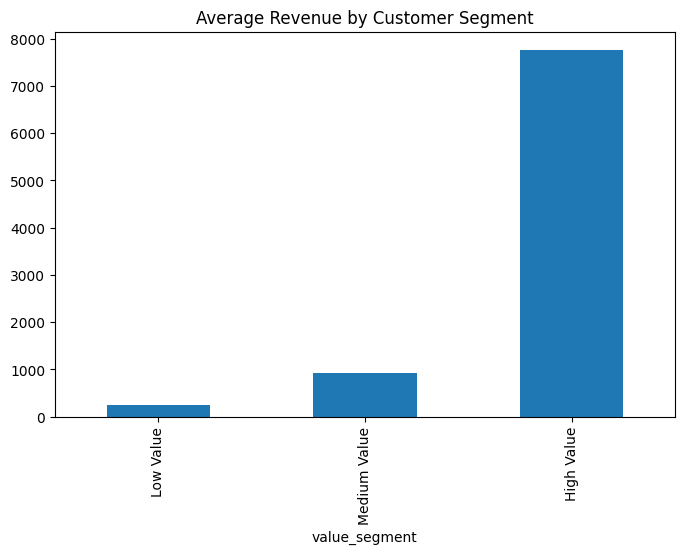

In [49]:
segment_analysis["total_revenue"].plot(
    kind="bar",
    title="Average Revenue by Customer Segment",
    figsize=(8,5)
)

<Axes: title={'center': 'Customer Distribution by Segment'}, xlabel='value_segment'>

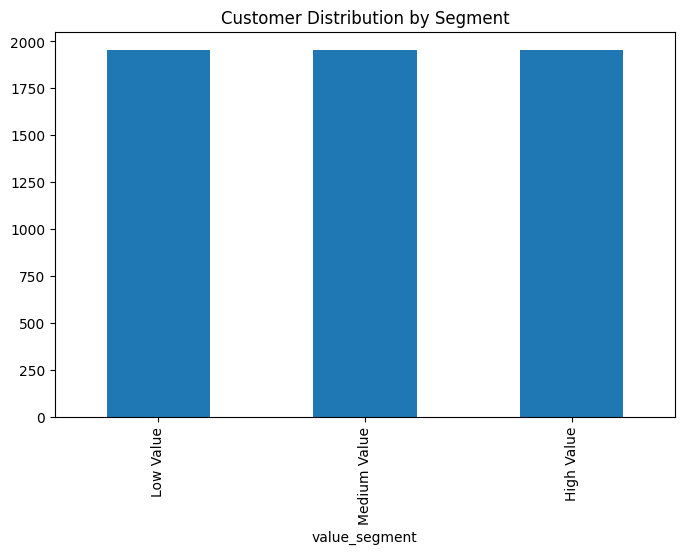

In [50]:
customer_df["value_segment"].value_counts().plot(
    kind="bar",
    title="Customer Distribution by Segment",
    figsize=(8,5)
)

In [51]:
customer_df.sort_values("total_revenue", ascending=False).head(10)

,customer_id,recency_days,frequency_orders,total_revenue,total_quantity,avg_order_value,log_revenue,log_frequency,value_segment
5676,18102.0,1,145,608821.65,188340,4198.770000,13.319282,4.983607,High Value
2270,14646.0,2,145,526751.52,367072,3632.769103,13.174486,4.983607,High Value
1785,14156.0,10,151,305767.92,165987,2024.953113,12.630585,5.023881,High Value
2528,14911.0,1,379,284592.97,149968,750.904934,12.558819,5.940171,High Value
5036,17450.0,8,51,246973.09,84720,4842.609608,12.417039,3.951244,High Value
1328,13694.0,4,143,196482.81,189205,1374.005664,12.188335,4.969813,High Value
5095,17511.0,3,60,175603.55,119656,2926.725833,12.075990,4.110874,High Value
4047,16446.0,1,2,168472.50,80997,84236.250000,12.034534,1.098612,High Value
4281,16684.0,4,55,147142.77,104810,2675.323091,11.899165,4.025352,High Value
68,12415.0,24,24,144033.37,91443,6001.390417,11.877807,3.218876,High Value


In [53]:
customer_df["rf_score"] = (
    customer_df["frequency_orders"].rank(pct=True) +
    customer_df["total_revenue"].rank(pct=True) -
    customer_df["recency_days"].rank(pct=True)
)